# MedQA — CLAMBER Uncertainty Analysis

Reads the generation + classification outputs from Experiments 2 & 3 and produces:
1. Overall accuracy progression (prelim → CQ1 → CQ2 → final)
2. Per-difficulty breakdown (easy / medium / hard)
3. CQ-type distribution per turn (EPISTEMIC vs ALEATORIC)
4. Accuracy gain by CQ type
5. Confidence calibration (Expected Calibration Error)
6. McNemar's test — is the prelim → final improvement significant?
7. Simulator grounding rate (how often the simulator says "not available")
8. CQ lexical diversity across turns

**Designed for reuse:** change `MODEL_ID` and `DATASET` to run the same analysis
on a different model or domain without touching any analysis code.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../../").resolve()))

DATASET   = "medqa"
MODEL_ID  = "gemini-2.5-flash"
ROOT      = Path("../../").resolve()
OUTPUTS   = ROOT / "outputs" / DATASET / MODEL_ID

import warnings, logging
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)
sns.set_theme(style="whitegrid", palette="muted")
FIGSIZE = (9, 5)

print(f"Outputs directory: {OUTPUTS}")
print(f"Exists: {OUTPUTS.exists()}")


Outputs directory: D:\final_project\pilot_study\outputs\medqa\gemini-2.5-flash
Exists: True


## 1. Load Data

In [2]:
# ── Multi-turn (Experiment 3: 100 cases, 3 CQ rounds) ────────────────────────
mt_results = pd.read_csv(OUTPUTS / "phase1_multiturn_results.csv")
mt_labels  = pd.read_csv(OUTPUTS / "phase1_multiturn_classified.csv")

# ── Single-turn (Experiment 2: same 100 cases, 1 CQ round) ───────────────────
st_results = pd.read_csv(OUTPUTS / "phase1_singleturn_results.csv")
st_labels  = pd.read_csv(OUTPUTS / "phase1_singleturn_classified.csv")

# Exclude blocked rows for analysis
mt = mt_results[~mt_results["was_blocked"]].copy()
st = st_results[~st_results["was_blocked"]].copy()

print(f"Multi-turn:  {len(mt_results)} rows, {mt_results['was_blocked'].sum()} blocked → {len(mt)} usable")
print(f"Single-turn: {len(st_results)} rows, {st_results['was_blocked'].sum()} blocked → {len(st)} usable")
assert set(mt["id"]) == set(st["id"]), "Dataset mismatch — not same 100 cases"
print(f"\nOverlap check: PASSED — same {len(mt)} cases in both experiments")


Multi-turn:  100 rows, 0 blocked → 100 usable
Single-turn: 100 rows, 0 blocked → 100 usable

Overlap check: PASSED — same 100 cases in both experiments


## 2. Overall Accuracy Progression

Multi-turn accuracy:
  Prelim (T0): 60.0%
  After CQ1: 67.0%
  After CQ2: 80.0%
  Final (CQ3): 83.0%

Single-turn accuracy:
  Prelim (T0): 63.0%
  After CQ1: 73.0%



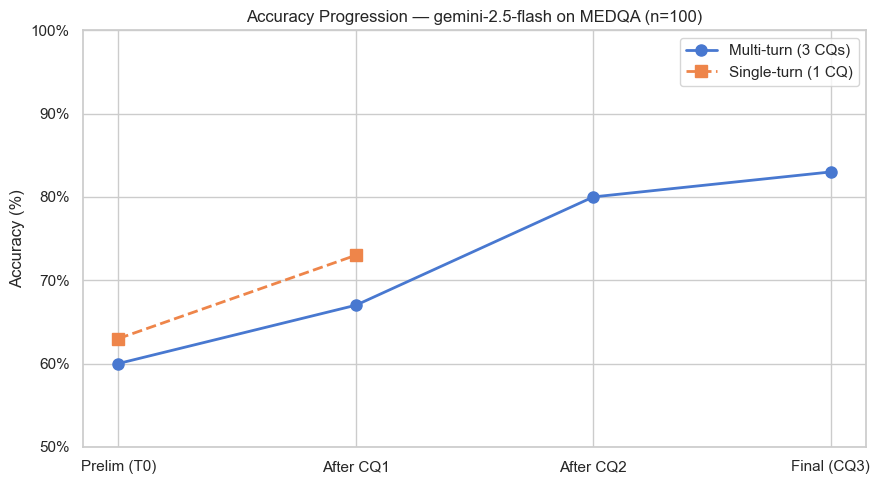

Saved: fig_accuracy_progression.png


In [3]:
def pct(series): return series.mean() * 100

# Multi-turn checkpoints
mt_acc = {
    "Prelim (T0)":   pct(mt["is_correct_preliminary"]),
    "After CQ1":     pct(mt["is_correct_1"]),
    "After CQ2":     pct(mt["is_correct_2"]),
    "Final (CQ3)":   pct(mt["is_correct_final"]),
}

# Single-turn checkpoints (same dataset)
st_acc = {
    "Prelim (T0)":   pct(st["is_correct_preliminary"]),
    "After CQ1":     pct(st["is_correct_updated"]),
}

print("Multi-turn accuracy:")
for k, v in mt_acc.items(): print(f"  {k}: {v:.1f}%")
print()
print("Single-turn accuracy:")
for k, v in st_acc.items(): print(f"  {k}: {v:.1f}%")
print()

# Plot
labels_mt  = list(mt_acc.keys())
values_mt  = list(mt_acc.values())
labels_st  = ["Prelim (T0)", "After CQ1"]
values_st  = list(st_acc.values())

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(labels_mt, values_mt, "o-", lw=2, ms=8, label="Multi-turn (3 CQs)")
ax.plot(labels_st, values_st, "s--", lw=2, ms=8, label="Single-turn (1 CQ)")
ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Accuracy Progression — {MODEL_ID} on {DATASET.upper()} (n={len(mt)})")
ax.set_ylim(50, 100)
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(OUTPUTS / "fig_accuracy_progression.png", dpi=150)
plt.show()
print("Saved: fig_accuracy_progression.png")


## 3. Per-Difficulty Breakdown

Multi-turn accuracy by difficulty:


,n,Prelim,After CQ1,After CQ2,Final
difficulty,,,,,
easy,50,68.0,70.0,82.0,80.0
medium,30,53.3,60.0,76.7,90.0
hard,20,50.0,70.0,80.0,80.0


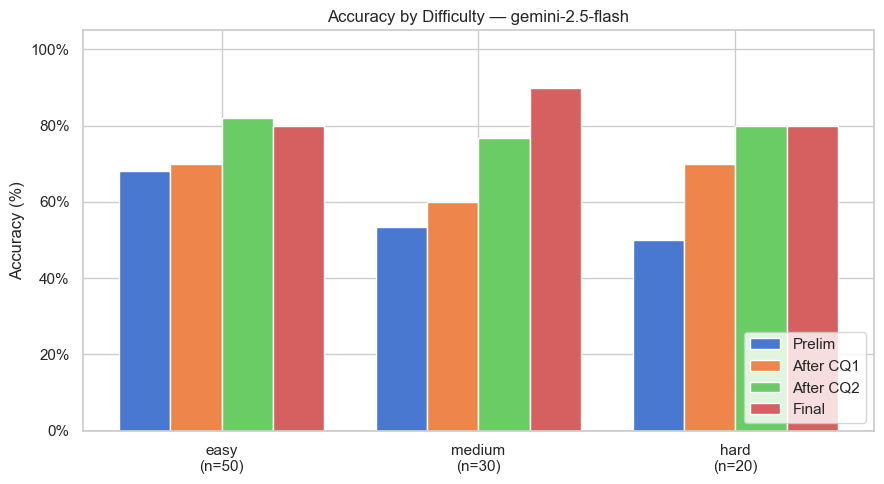

Saved: fig_accuracy_by_difficulty.png


In [4]:
difficulties = ["easy", "medium", "hard"]
checkpoints  = {
    "Prelim":     "is_correct_preliminary",
    "After CQ1":  "is_correct_1",
    "After CQ2":  "is_correct_2",
    "Final":      "is_correct_final",
}

rows = []
for diff in difficulties:
    sub = mt[mt["difficulty"] == diff]
    n   = len(sub)
    row = {"difficulty": diff, "n": n}
    for label, col in checkpoints.items():
        row[label] = pct(sub[col]) if n else float("nan")
    rows.append(row)

diff_df = pd.DataFrame(rows).set_index("difficulty")
print("Multi-turn accuracy by difficulty:")
display(diff_df.round(1))

# Plot
fig, ax = plt.subplots(figsize=FIGSIZE)
x = np.arange(len(difficulties))
width = 0.2
for i, (label, col) in enumerate(checkpoints.items()):
    vals = [pct(mt[mt["difficulty"] == d][col]) for d in difficulties]
    ax.bar(x + i*width, vals, width, label=label)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"{d}\n(n={len(mt[mt['difficulty']==d])})" for d in difficulties])
ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Accuracy by Difficulty — {MODEL_ID}")
ax.legend(loc="lower right")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(OUTPUTS / "fig_accuracy_by_difficulty.png", dpi=150)
plt.show()
print("Saved: fig_accuracy_by_difficulty.png")


## 4. CQ Type Distribution per Turn

In [5]:
# Normalise column name: classified CSV uses 'question' not 'clarifying_question'
q_col = "question" if "question" in mt_labels.columns else "clarifying_question"

# Merge turn info if not present
if "turn" not in mt_labels.columns:
    # Rebuild from multiturn results: melt CQ columns
    long_rows = []
    for _, r in mt.iterrows():
        for t in range(1, 4):
            long_rows.append({"id": r["id"], "turn": t, q_col: r[f"cq_{t}"]})
    long_df = pd.DataFrame(long_rows)
    mt_labels_merged = mt_labels.merge(
        long_df.rename(columns={q_col: "question"})[["id", "turn", "question"]],
        on=["id", "question"], how="left"
    )
else:
    mt_labels_merged = mt_labels.copy()

valid = mt_labels_merged[mt_labels_merged["label"].isin({"EPISTEMIC", "ALEATORIC"})]

print(f"Total CQs classified: {len(valid)}")
print()
print("Overall label distribution:")
print(valid["label"].value_counts().to_string())
print()
print("Label distribution by turn:")
dist = valid.groupby(["turn", "label"]).size().unstack(fill_value=0)
display(dist)


Total CQs classified: 300

Overall label distribution:
label
EPISTEMIC    293
ALEATORIC      7

Label distribution by turn:


label,ALEATORIC,EPISTEMIC
turn,,
1,4,96
2,2,98
3,1,99


## 5. Accuracy Gain by CQ Type

In [6]:
# For each turn, compare cases where CQ was EPISTEMIC vs ALEATORIC
# Accuracy BEFORE turn k = is_correct at previous checkpoint
# Accuracy AFTER  turn k = is_correct at current checkpoint

before_col = {1: "is_correct_preliminary", 2: "is_correct_1", 3: "is_correct_2"}
after_col  = {1: "is_correct_1",           2: "is_correct_2", 3: "is_correct_final"}

results = []
for turn in [1, 2, 3]:
    turn_labels = valid[valid["turn"] == turn][["id", "label"]].copy()
    turn_labels.columns = ["id", "cq_label"]
    merged = mt.merge(turn_labels, on="id", how="inner")
    for label in ["EPISTEMIC", "ALEATORIC"]:
        sub = merged[merged["cq_label"] == label]
        if len(sub) == 0:
            continue
        acc_before = pct(sub[before_col[turn]])
        acc_after  = pct(sub[after_col[turn]])
        results.append({
            "turn": turn,
            "cq_type": label,
            "n": len(sub),
            "acc_before (%)": round(acc_before, 1),
            "acc_after (%)":  round(acc_after,  1),
            "delta (pp)":     round(acc_after - acc_before, 1),
        })

gain_df = pd.DataFrame(results)
print("Accuracy gain by CQ type and turn:")
display(gain_df)

note = (
    "Note: ALEATORIC n is very small (1-2 per turn) — delta values are not "
    "statistically interpretable for this subgroup."
)
print(f"\n{note}")


Accuracy gain by CQ type and turn:


,turn,cq_type,n,acc_before (%),acc_after (%),delta (pp)
0,1,EPISTEMIC,96,59.4,66.7,7.3
1,1,ALEATORIC,4,75.0,75.0,0.0
2,2,EPISTEMIC,98,66.3,79.6,13.3
3,2,ALEATORIC,2,100.0,100.0,0.0
4,3,EPISTEMIC,99,79.8,82.8,3.0
5,3,ALEATORIC,1,100.0,100.0,0.0



Note: ALEATORIC n is very small (1-2 per turn) — delta values are not statistically interpretable for this subgroup.


## 6. Confidence Calibration (Expected Calibration Error)

Expected Calibration Error (ECE) — lower is better:
  Prelim: ECE = 17.25 pp
  CQ1: ECE = 14.50 pp
  CQ2: ECE = 9.14 pp
  Final: ECE = 12.70 pp


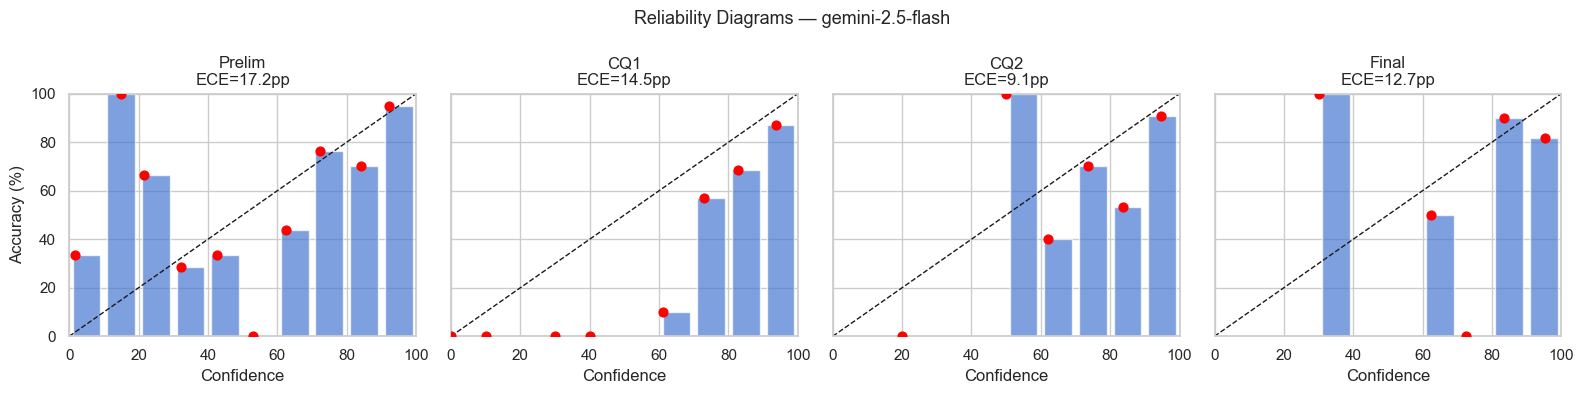

Saved: fig_calibration.png


In [7]:
def compute_ece(confidences, correctness, n_bins=10):
    """Expected Calibration Error over equal-width bins [0, 100]."""
    bins = np.linspace(0, 100, n_bins + 1)
    ece = 0.0
    bin_data = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences >= lo) & (confidences < hi)
        if mask.sum() == 0:
            bin_data.append({"bin_mid": (lo+hi)/2, "acc": np.nan, "conf": np.nan, "n": 0})
            continue
        acc_bin  = correctness[mask].mean() * 100
        conf_bin = confidences[mask].mean()
        ece += mask.sum() * abs(acc_bin - conf_bin)
        bin_data.append({"bin_mid": (lo+hi)/2, "acc": acc_bin, "conf": conf_bin, "n": int(mask.sum())})
    return ece / len(confidences), pd.DataFrame(bin_data)

checkpoints_conf = [
    ("Prelim",  "preliminary_confidence", "is_correct_preliminary"),
    ("CQ1",     "confidence_1",           "is_correct_1"),
    ("CQ2",     "confidence_2",           "is_correct_2"),
    ("Final",   "final_confidence",       "is_correct_final"),
]

print("Expected Calibration Error (ECE) — lower is better:")
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (label, conf_col, corr_col) in zip(axes, checkpoints_conf):
    confs = mt[conf_col].dropna()
    corrs = mt[corr_col].dropna()
    idx   = confs.index.intersection(corrs.index)
    ece_val, bin_df = compute_ece(confs.loc[idx].values, corrs.loc[idx].values)
    print(f"  {label}: ECE = {ece_val:.2f} pp")

    valid_bins = bin_df.dropna()
    ax.bar(valid_bins["bin_mid"], valid_bins["acc"], width=8, alpha=0.7, label="Accuracy")
    ax.plot([0, 100], [0, 100], "k--", lw=1, label="Perfect")
    ax.scatter(valid_bins["conf"], valid_bins["acc"], s=40, color="red", zorder=5)
    ax.set_title(f"{label}\nECE={ece_val:.1f}pp")
    ax.set_xlabel("Confidence")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

axes[0].set_ylabel("Accuracy (%)")
fig.suptitle(f"Reliability Diagrams — {MODEL_ID}", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / "fig_calibration.png", dpi=150)
plt.show()
print("Saved: fig_calibration.png")


## 7. Statistical Significance (McNemar's Test)

In [8]:
def mcnemar_test(before, after, name):
    """McNemar's test: is the change in binary outcomes significant?"""
    from scipy.stats import binomtest
    # Contingency: b = gained correct, c = lost correct
    b = int(((~before) & after).sum())   # wrong → correct
    c = int((before & (~after)).sum())   # correct → wrong
    total = b + c
    if total == 0:
        print(f"{name}: no discordant pairs — trivially not significant")
        return
    # One-sided exact binomial test: H1 = more gains than losses
    p = binomtest(b, total, 0.5, alternative="greater").pvalue
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"{name}: +{b} gained, -{c} lost → p={p:.4f} {sig}")

print("McNemar's test (one-sided: did accuracy improve?):")
print()
mcnemar_test(mt["is_correct_preliminary"], mt["is_correct_1"],    "Prelim → CQ1")
mcnemar_test(mt["is_correct_1"],           mt["is_correct_2"],    "CQ1   → CQ2")
mcnemar_test(mt["is_correct_2"],           mt["is_correct_final"],"CQ2   → Final")
print()
mcnemar_test(mt["is_correct_preliminary"], mt["is_correct_final"],"Prelim → Final (overall)")
print()
print("Single-turn McNemar's:")
mcnemar_test(st["is_correct_preliminary"], st["is_correct_updated"], "Prelim → After CQ1")

McNemar's test (one-sided: did accuracy improve?):

Prelim → CQ1: +11 gained, -4 lost → p=0.0592 n.s.
CQ1   → CQ2: +13 gained, -0 lost → p=0.0001 ***
CQ2   → Final: +4 gained, -1 lost → p=0.1875 n.s.

Prelim → Final (overall): +26 gained, -3 lost → p=0.0000 ***

Single-turn McNemar's:
Prelim → After CQ1: +16 gained, -6 lost → p=0.0262 *


## 8. Simulator Grounding Rate

In [9]:
not_avail_phrase = "not available"

def grounding_rate(col):
    responses = mt[col].fillna("").str.lower()
    n_total = len(responses)
    n_unavailable = responses.str.contains(not_avail_phrase).sum()
    return n_unavailable, n_total, n_unavailable / n_total * 100

print("Simulator grounding rate (fraction where sim said 'not available'):")
for t in [1, 2, 3]:
    n_unav, n_tot, pct_unav = grounding_rate(f"patient_response_{t}")
    print(f"  CQ{t}: {n_unav}/{n_tot} ({pct_unav:.1f}%) not available")


Simulator grounding rate (fraction where sim said 'not available'):
  CQ1: 12/100 (12.0%) not available
  CQ2: 21/100 (21.0%) not available
  CQ3: 25/100 (25.0%) not available


## 9. CQ Lexical Diversity Across Turns

In [10]:
def jaccard(a, b):
    tok_a = set(str(a).lower().split())
    tok_b = set(str(b).lower().split())
    if not tok_a and not tok_b: return 1.0
    return len(tok_a & tok_b) / len(tok_a | tok_b)

pairs = [("cq_1", "cq_2"), ("cq_2", "cq_3"), ("cq_1", "cq_3")]
print("Mean token Jaccard similarity between consecutive CQs:")
print("(lower = more diverse; 0 = no shared tokens, 1 = identical)")
for ca, cb in pairs:
    sims = mt.apply(lambda r: jaccard(r[ca], r[cb]), axis=1)
    print(f"  {ca} vs {cb}: {sims.mean():.3f} (median {sims.median():.3f})")


Mean token Jaccard similarity between consecutive CQs:
(lower = more diverse; 0 = no shared tokens, 1 = identical)
  cq_1 vs cq_2: 0.134 (median 0.111)
  cq_2 vs cq_3: 0.132 (median 0.114)
  cq_1 vs cq_3: 0.119 (median 0.105)


## 10. Export Summary

In [11]:
# Per-case summary with all correctness columns + CQ types merged
cq_type_wide = {}
for turn in [1, 2, 3]:
    turn_lbl = mt_labels_merged[mt_labels_merged["turn"] == turn][["id", "label"]].rename(
        columns={"label": f"cq{turn}_type"}
    )
    cq_type_wide[turn] = turn_lbl

summary = mt[["id", "difficulty", "correct_option",
              "is_correct_preliminary", "is_correct_1", "is_correct_2", "is_correct_final",
              "preliminary_confidence", "confidence_1", "confidence_2", "final_confidence"]].copy()

for turn, df in cq_type_wide.items():
    summary = summary.merge(df, on="id", how="left")

out_path = OUTPUTS / "analysis_summary.csv"
summary.to_csv(out_path, index=False)
print(f"Summary saved: {out_path}")
print(f"  Rows: {len(summary)} | Columns: {list(summary.columns)}")
display(summary.head(5))


Summary saved: D:\final_project\pilot_study\outputs\medqa\gemini-2.5-flash\analysis_summary.csv
  Rows: 100 | Columns: ['id', 'difficulty', 'correct_option', 'is_correct_preliminary', 'is_correct_1', 'is_correct_2', 'is_correct_final', 'preliminary_confidence', 'confidence_1', 'confidence_2', 'final_confidence', 'cq1_type', 'cq2_type', 'cq3_type']


,id,difficulty,correct_option,is_correct_preliminary,is_correct_1,is_correct_2,is_correct_final,preliminary_confidence,confidence_1,confidence_2,final_confidence,cq1_type,cq2_type,cq3_type
0,medqa_0982,easy,B,True,True,True,True,35,95,95,100,EPISTEMIC,EPISTEMIC,EPISTEMIC
1,medqa_0799,easy,B,True,True,True,True,75,85,90,95,EPISTEMIC,EPISTEMIC,EPISTEMIC
2,medqa_1095,medium,C,True,True,True,True,15,90,90,90,EPISTEMIC,EPISTEMIC,EPISTEMIC
3,medqa_1228,hard,B,True,True,True,True,80,95,98,99,EPISTEMIC,EPISTEMIC,EPISTEMIC
4,medqa_1054,medium,A,True,True,True,True,65,85,95,98,EPISTEMIC,ALEATORIC,EPISTEMIC
